Starting SA-ES Tracking Loop...
Epoch 000 | Top MU Fidelity: 0.8495 | Amp Sigma: 0.1889
Epoch 020 | Top MU Fidelity: 0.8736 | Amp Sigma: 0.1201
Epoch 040 | Top MU Fidelity: 0.8771 | Amp Sigma: 0.0782
Epoch 060 | Top MU Fidelity: 0.8584 | Amp Sigma: 0.1030
Epoch 080 | Top MU Fidelity: 0.8736 | Amp Sigma: 0.0646
Epoch 100 | Top MU Fidelity: 0.8723 | Amp Sigma: 0.1419
Epoch 120 | Top MU Fidelity: 0.8754 | Amp Sigma: 0.1130
Epoch 140 | Top MU Fidelity: 0.8712 | Amp Sigma: 0.1190
SA-ES Optimization Complete!


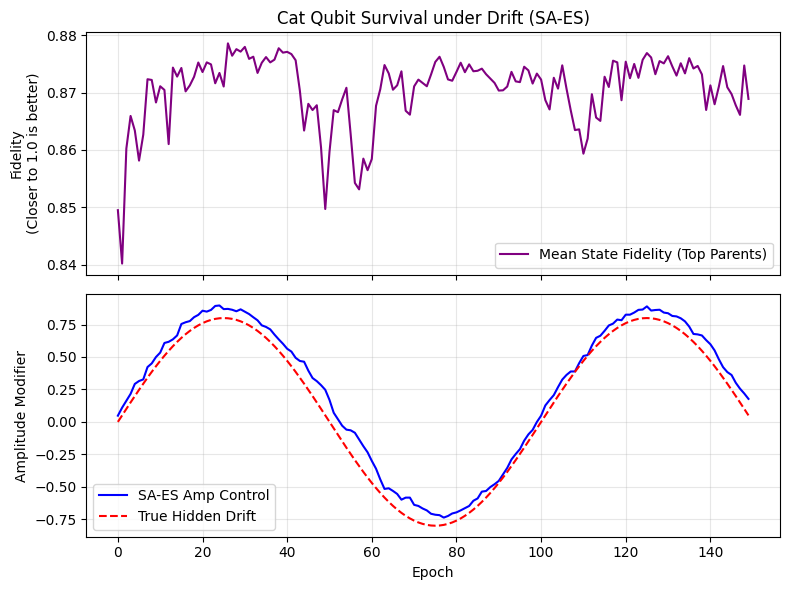

In [1]:
import jax
import jax.numpy as jnp
import dynamiqs as dq
import matplotlib.pyplot as plt

# =====================================================================
# 1. THE PHYSICS & FIDELITY REWARD
# =====================================================================
@jax.jit
def cat_qubit_proxy_reward(p, epoch):
    amp_modifier = p[0]
    detuning = p[1]

    drift = 0.8 * jnp.sin(2 * jnp.pi * 0.01 * epoch)
    current_amp_modifier = amp_modifier - drift

    na, nb = 15, 5
    a = dq.tensor(dq.destroy(na), dq.eye(nb))
    b = dq.tensor(dq.eye(na), dq.destroy(nb))

    kappa_b, g_2, kappa_a = 10.0, 1.0, 1.0
    eps_d = 4.0 * (1.0 + current_amp_modifier)

    H = jnp.conj(g_2) * a @ a @ b.dag() + g_2 * a.dag() @ a.dag() @ b - eps_d * b.dag() - jnp.conj(eps_d) * b + detuning * a.dag() @ a
    loss_b, loss_a = jnp.sqrt(kappa_b) * b, jnp.sqrt(kappa_a) * a

    eps_2_ideal = 2 * g_2 * 4.0 / kappa_b
    kappa_2 = 4 * jnp.abs(g_2)**2 / kappa_b
    alpha_estimate = jnp.sqrt(2/kappa_2 * (eps_2_ideal - kappa_a/4))
    psi0 = dq.tensor(dq.coherent(na, alpha_estimate), dq.fock(nb, 0))

    tsave = jnp.linspace(0, 5.0, 2)
    res = dq.mesolve(H, [loss_b, loss_a], psi0, tsave, options=dq.Options(progress_meter=False))

    rho = res.states[-1]
    fidelity = (psi0.dag() @ rho @ psi0).real[0, 0]

    return 1.0 - fidelity

batched_cat_reward = jax.vmap(cat_qubit_proxy_reward, in_axes=(0, None))


# =====================================================================
# 2. THE SA-ES OPTIMIZER LOOP
# =====================================================================
N_EPOCHS = 150
LAMBDA = 32      # Population size (Offspring)
MU = 16          # Number of parents to select
N_PARAMS = 2

# SA-ES Hyperparameters
TAU = 1.0 / jnp.sqrt(2.0 * N_PARAMS) # Learning rate for Sigma
MIN_SIGMA = 0.05
MAX_SIGMA = 0.3

# Initial State
mean = jnp.array([0.0, 0.0])
# SA-ES tracks independent sigmas for each parameter!
sigma = jnp.array([0.2, 0.2])

key = jax.random.PRNGKey(42)

mean_history = []
reward_history = []

print("Starting SA-ES Tracking Loop...")
for epoch in range(N_EPOCHS):
    # Split JAX PRNG keys for random mutations
    key, key_sigma, key_x = jax.random.split(key, 3)

    # 1. Mutate the Step Sizes (Self-Adaptation)
    # The AI randomly guesses larger or smaller search radii
    noise_sigma = jax.random.normal(key_sigma, (LAMBDA, N_PARAMS))
    sigmas_offspring = sigma * jnp.exp(TAU * noise_sigma)
    sigmas_offspring = jnp.clip(sigmas_offspring, MIN_SIGMA, MAX_SIGMA)

    # 2. Mutate the Parameters using the new Step Sizes
    noise_x = jax.random.normal(key_x, (LAMBDA, N_PARAMS))
    xs_offspring = mean + sigmas_offspring * noise_x

    # Clip parameters to hardware bounds
    xs_offspring = jnp.clip(xs_offspring,
                            jnp.array([-2.0, -5.0]),
                            jnp.array([2.0, 5.0]))

    # 3. Evaluate the Population
    losses = batched_cat_reward(xs_offspring, float(epoch))
    losses = jnp.where(jnp.isnan(losses), 1.0, losses) # Failsafe

    # 4. Selection (Find the Top MU performers)
    sort_indices = jnp.argsort(losses)
    best_indices = sort_indices[:MU]

    # 5. Recombination (Update parents to the center of the best offspring)
    mean = jnp.mean(xs_offspring[best_indices], axis=0)
    sigma = jnp.mean(sigmas_offspring[best_indices], axis=0)

    # Logging
    mean_batch_loss = float(jnp.mean(losses[best_indices]))
    mean_history.append(mean)
    reward_history.append(1.0 - mean_batch_loss)

    if epoch % 20 == 0:
        print(f"Epoch {epoch:03d} | Top MU Fidelity: {(1.0 - mean_batch_loss):.4f} | Amp Sigma: {sigma[0]:.4f}")

print("SA-ES Optimization Complete!")


# =====================================================================
# 3. VISUALIZATION
# =====================================================================
epochs = jnp.arange(N_EPOCHS)
mean_history = jnp.array(mean_history)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

ax1.plot(epochs, reward_history, color='purple', label="Mean State Fidelity (Top Parents)")
ax1.set_ylabel("Fidelity\n(Closer to 1.0 is better)")
ax1.set_title("Cat Qubit Survival under Drift (SA-ES)")
ax1.grid(True, alpha=0.3)
ax1.legend()

true_drift = 0.8 * jnp.sin(2 * jnp.pi * 0.01 * epochs)
ax2.plot(epochs, mean_history[:, 0], color='blue', label="SA-ES Amp Control")
ax2.plot(epochs, true_drift, color='red', linestyle='--', label="True Hidden Drift")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Amplitude Modifier")
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()